# Import required packages


In [36]:
import xml.etree.ElementTree as ET
from pathlib import Path
from pprint import pprint

import networkx as nx
from ipysigma import Sigma, SigmaGrid

# Open the sample MARCXML file containing the downloaded bibliographic records


In [37]:
filename = "salinger_example.marcxml"

file_path = Path.cwd() / "data" / "in" / filename

try:
    tree = ET.parse(file_path)
    root = tree.getroot()
except FileNotFoundError:
    print("XML file not found.")
except ET.ParseError:
    print("Invalid XML file.")

# Extract the bibliographic catalogue data from the MARCXML file


In [39]:
ns = { "marc21": "http://www.loc.gov/MARC21/slim" }

catalogue_items = root.findall("marc21:record", ns)

# Define edges and nodes for the graph representation of the bibliographic data

In [40]:
edges = []
nodes = {}

# Iterate through each bibliographic record and extract the relevant information


In [42]:
item_dict_list = []

for x in catalogue_items:

        if x is not None:
            itemdata = x
            # Create a dictionary for each catalogue item
            topics = itemdata.findall("marc21:datafield[@tag='650']", ns)
            for topic in topics:
                item = {
                    "isbn": itemdata.find("marc21:datafield[@tag='020']", ns).findtext("marc21:subfield[@code='a']", namespaces=ns, default=None),
                    "title": itemdata.find("marc21:datafield[@tag='245']", ns).findtext("marc21:subfield[@code='a']", namespaces=ns, default=None),
                    "date": itemdata.find("marc21:datafield[@tag='260']", ns).findtext("marc21:subfield[@code='c']", namespaces=ns, default=None).replace(".",""),
                    "pref_subject": topic.findtext("marc21:subfield[@code='a']", namespaces=ns, default=None)
                }
                item_dict_list.append(item)

                # Define edges for the catalogue graph
                # Add edges based on the relationships between titles and subjects
                if (
                    item["title"] is not None
                    and item["pref_subject"] is not None
                ):
                    edges.append((item["pref_subject"], item["title"]))

            # Define nodes for the catalogue graph
            keys_title_to_extract = ["title", "pref_subject", "date", "isbn"]
            keys_subject_to_extract = ["pref_subject"]
            for node_attributes in item_dict_list:
                node_title = node_attributes["title"]
                node_pref_subject = node_attributes["pref_subject"]

                # Create sub-dictionaries for title and subject nodes with relevant attributes
                sub_dict_title = {key: node_attributes[key] for key in keys_title_to_extract if key in node_attributes and node_attributes[key] is not None}
                sub_dict_title["type"] = "book"
                sub_dict_subject = {key: node_attributes[key] for key in keys_subject_to_extract if key in node_attributes and node_attributes[key] is not None}
                sub_dict_subject["type"] = "subject"
                
                if node_title is not None:
                    nodes[node_title] = sub_dict_title
                if node_pref_subject is not None:
                    nodes[node_pref_subject] = sub_dict_subject

# Inspect nodes and edges


In [43]:

# Print the first 5 edges for verification
pprint("*****")
pprint("* Inspect The first 5 edges:")
pprint("*****")
pprint(edges[:5])
print("\n")
# Print the first 5 nodes for verification
pprint("*****")
pprint("* Inspect The first 5 nodes:")
pprint("*****")
pprint(dict(list(nodes.items())[:5]))

'*****'
'* Inspect The first 5 edges:'
'*****'
[('Caulfield, Holden (Fictitious character)', 'The catcher in the rye /'),
 ('Runaway teenagers', 'The catcher in the rye /'),
 ('Teenage boys', 'The catcher in the rye /'),
 ('Caulfield, Holden (Fictitious character)', 'The catcher in the rye /'),
 ('Runaway teenagers', 'The catcher in the rye /')]


'*****'
'* Inspect The first 5 nodes:'
'*****'
{'Caulfield, Holden (Fictitious character)': {'pref_subject': 'Caulfield, '
                                                              'Holden '
                                                              '(Fictitious '
                                                              'character)',
                                              'type': 'subject'},
 'Runaway teenagers': {'pref_subject': 'Runaway teenagers', 'type': 'subject'},
 'Teenage boys': {'pref_subject': 'Teenage boys', 'type': 'subject'},
 'The catcher in the rye /': {'date': '2010',
                              'isbn': '9

# Draw NetworkX Graph


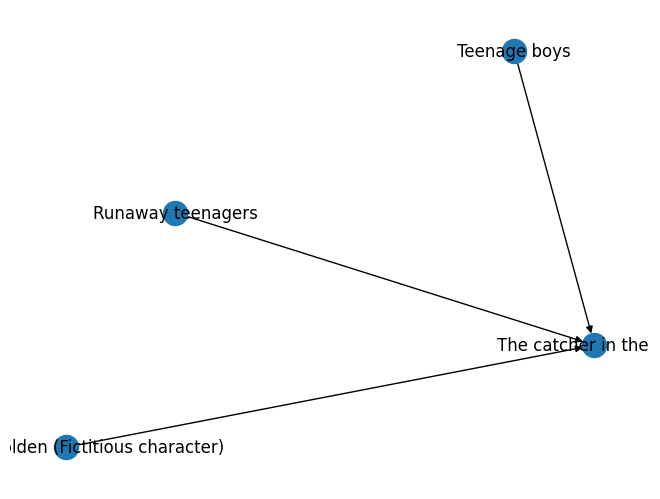

In [44]:
G = nx.DiGraph()
for edge in edges:
    G.add_edge(edge[0], edge[1])

nx.set_node_attributes(G, nodes)
nx.draw(G, with_labels=True)

# Create a Sigma visualization


In [45]:
Sigma(
    G,
    node_metrics=["louvain"],
    node_color="pref_subject",
    node_size_range=(3, 30),
    max_categorical_colors=50,
    default_edge_type="curve",
    default_node_label_size=14,
    node_size=G.degree,
    label_density=2
    )

Sigma(nx.DiGraph with 4 nodes and 3 edges)

## With custom icons for both types of nodes (title vs. subject heading).


In [47]:
Sigma(
    G,
    node_metrics=["louvain"],
    node_color="pref_subject",
    node_size_range=(3, 30),
    node_shape = "type",
    node_shape_mapping = {
        "book": "book_2",
        "subject": "label"
        },
    max_categorical_colors=50,
    default_edge_type="curve",
    default_node_label_size=14,
    node_size=G.degree,
    label_density=2
    )

Sigma(nx.DiGraph with 4 nodes and 3 edges)